In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Getting the share market data
df = pd.read_csv("/content/NIFTY 200-05-11-2025-to-05-12-2025.csv")




In [ ]:

df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,04-DEC-2025,14446.40,14511.60,14427.60,14466.40,2085433529,49722.55
1,03-DEC-2025,14501.45,14524.90,14400.80,14444.40,2196622215,51259.47
2,02-DEC-2025,14536.10,14575.15,14485.40,14508.95,2143354585,55963.05
3,01-DEC-2025,14642.65,14642.65,14538.70,14571.35,1581452832,43684.64
4,28-NOV-2025,14597.10,14611.70,14561.85,14579.35,1277203262,43024.96


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             21 non-null     object 
 1   Open             21 non-null     float64
 2   High             21 non-null     float64
 3   Low              21 non-null     float64
 4   Close            21 non-null     float64
 5   Shares Traded    21 non-null     int64  
 6   Turnover (₹ Cr)  21 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.3+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
count,21.000000,21.000000,21.000000,21.000000,2.100000e+01,21.000000
mean,14468.088095,14514.090476,14412.147619,14464.892857,1.885497e+09,56540.751429
std,112.272158,95.857973,112.404208,101.216891,4.581427e+08,13614.407967
min,14207.850000,14291.850000,14124.600000,14251.000000,1.267905e+09,43024.960000
25%,14417.950000,14487.600000,14392.500000,14412.850000,1.491766e+09,49438.760000
50%,14484.050000,14534.500000,14427.600000,14472.150000,1.859841e+09,52127.800000
75%,14546.700000,14575.150000,14484.100000,14541.450000,2.196622e+09,59380.280000
max,14642.650000,14642.650000,14561.850000,14585.350000,2.964577e+09,106216.690000


In [ ]:
df.isnull()


,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()


,0
Date,0
Open,0
High,0
Low,0
Close,0
Shares Traded,0
Turnover (₹ Cr),0


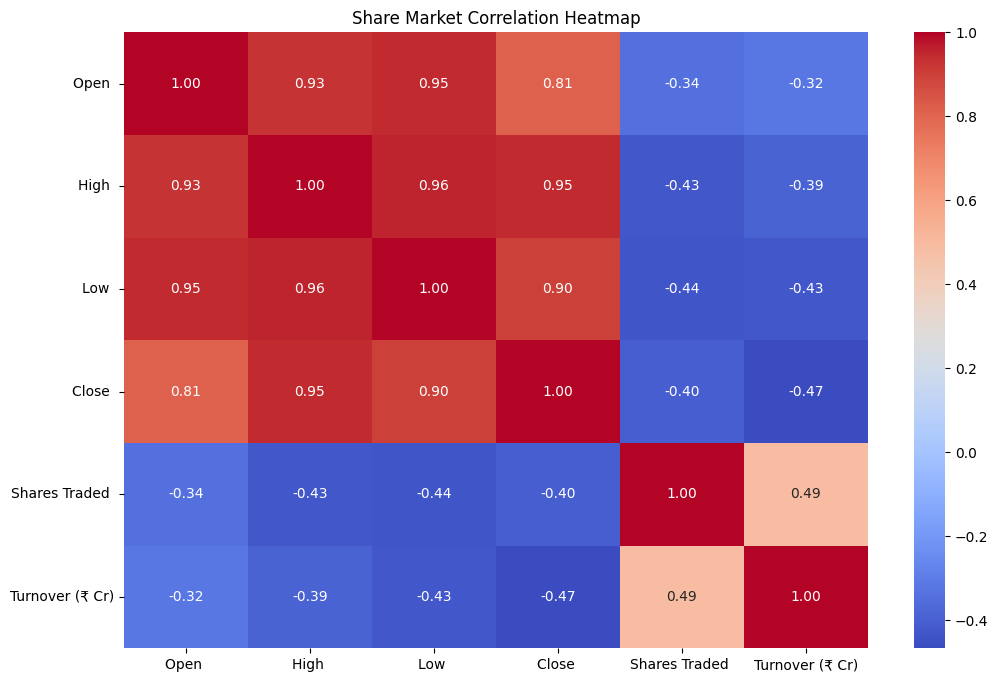

In [ ]:
plt.figure(figsize=(12, 8))
# Correlation heatmap for share-market data
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Share Market Correlation Heatmap")
plt.show()

In [ ]:
column_name = "Close"
if column_name in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column_name], bins=20, kde=True)
    plt.title("Distribution of Close Price")
    plt.xlabel("Close Price")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("Column 'Close' not found. Available columns are:")
    print(df.columns)

Column 'Close' not found. Available columns are:
Index(['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (₹ Cr)'],
      dtype='object')


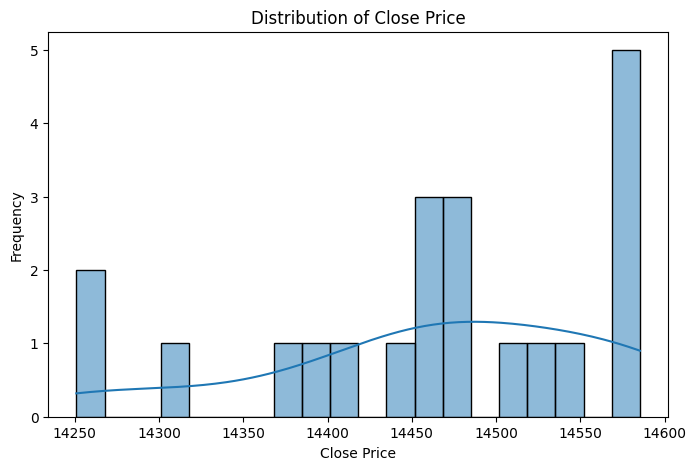

In [ ]:
plt.figure(figsize=(8,5))
# Histogram of Close price
sns.histplot(df['Close '], bins=20, kde=True)
plt.title("Distribution of Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()


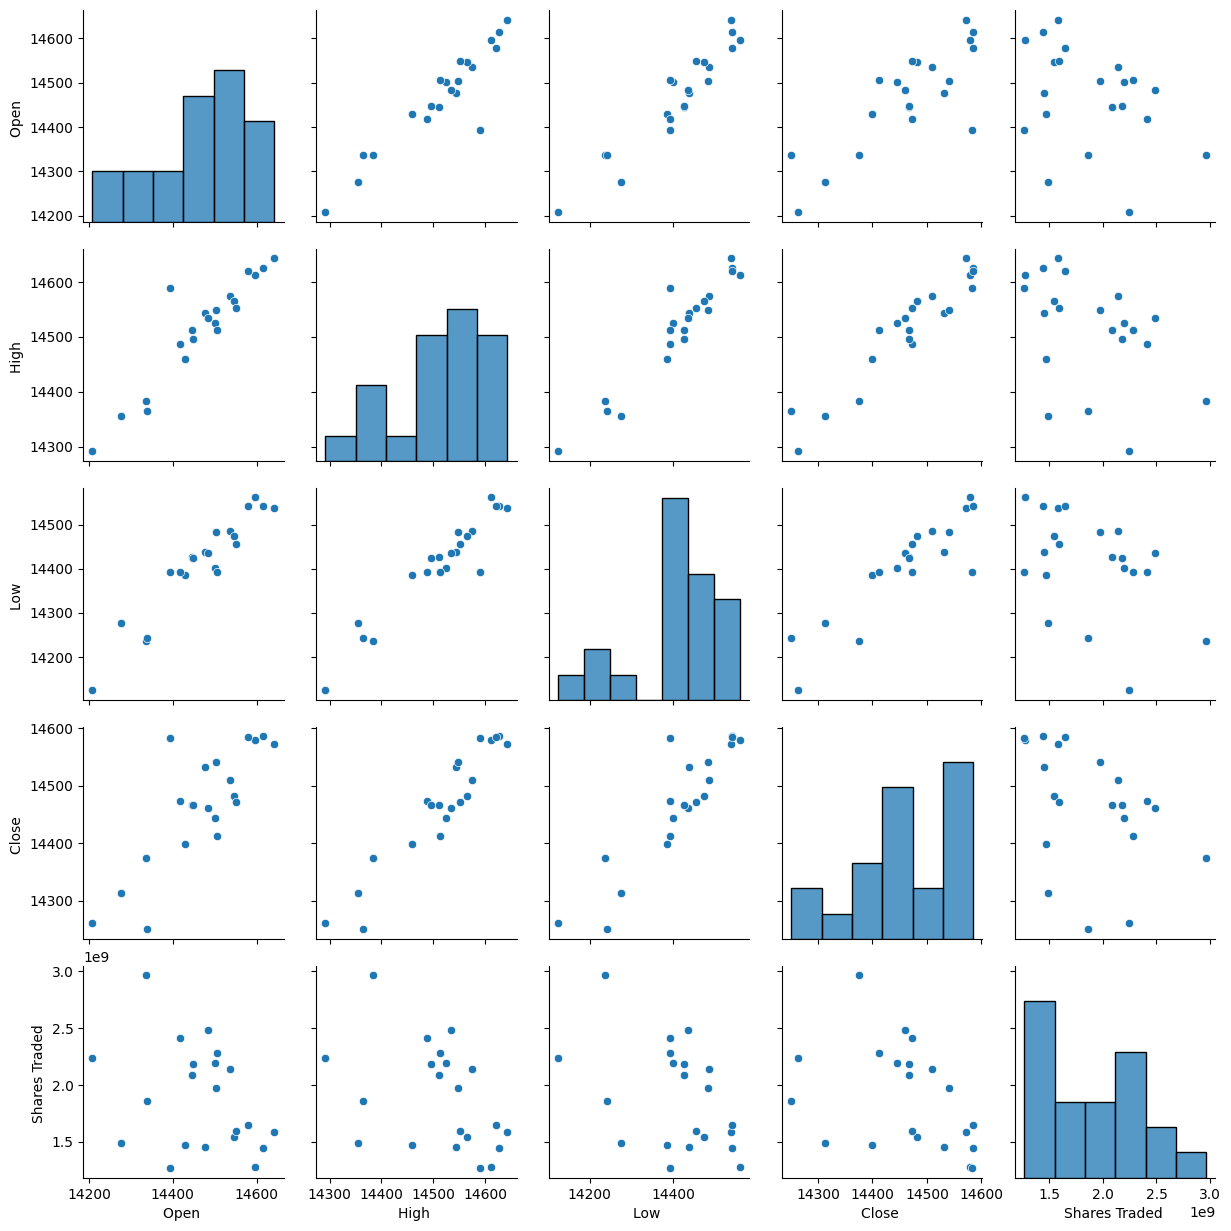

In [ ]:
# Select numeric share-market features
numeric_features = ['Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ']
# Pairplot
sns.pairplot(df[numeric_features])
plt.show()


In [ ]:

# Feature selection for share market dataset
features = ['Open ', 'High ', 'Low ', 'Shares Traded ']   # independent variables
X = df[features]
# Target variable (what we want to predict)
y = df['Close ']


In [ ]:
# Features and target
X = df[['Open ', 'High ', 'Low ', 'Shares Traded ']]
y = df['Close ']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:

model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:

print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)


Intercept: -1223.966800028984
Coefficients: [-7.03491865e-01  1.27791983e+00  5.05619311e-01  1.85070008e-08]


In [ ]:
y_pred=model.predict(X_test)


In [ ]:
y_pred

array([14491.23801761, 14325.44258687, 14505.23798406, 14458.01429575,
       14437.31711165])

In [ ]:
mse=mean_squared_error(y_test,y_pred)

In [ ]:
mse

1173.7517119288627

In [ ]:
r2=r2_score(y_test,y_pred)



In [ ]:
r2

-0.020514695067499922

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [ ]:
np.random.seed(42)
X = np.linspace(-3, 3, 80).reshape(-1, 1)
y = 2 * X**2 + 3 * X + 5 + np.random.randn(80, 1) * 3


In [ ]:
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)



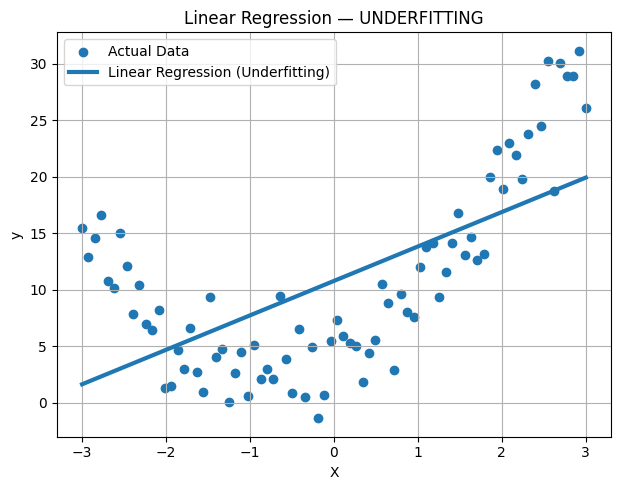

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred_lr, label="Linear Regression (Underfitting)", linewidth=3)
plt.title("Linear Regression — UNDERFITTING")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0



In [ ]:
print("Dataset loaded successfully!")
print("Train shape:", x_train.shape)
print("Test shape: ", x_test.shape)

Dataset loaded successfully!
Train shape: (50000, 32, 32, 3)
Test shape:  (10000, 32, 32, 3)


In [ ]:
small_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
small_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_small = small_model.fit(
    x_train, y_train,
    epochs=2,
    validation_data=(x_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4023 - loss: 1.6540 - val_accuracy: 0.6073 - val_loss: 1.1357
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6144 - loss: 1.1015 - val_accuracy: 0.6530 - val_loss: 1.0000


In [ ]:
big_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.0),   # intentionally removed regularization
    layers.Dense(10, activation='softmax')
])
big_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_big = big_model.fit(
    x_train, y_train,
    epochs=1,
    validation_data=(x_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1297s 828ms/step - accuracy: 0.1031 - loss: 2.3031 - val_accuracy: 0.1000 - val_loss: 2.3027


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


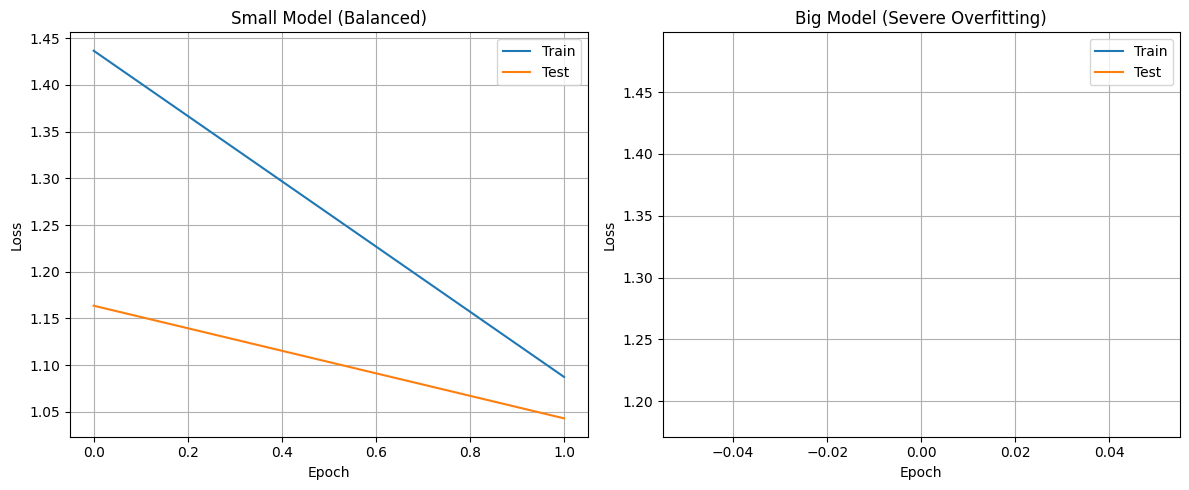

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess data (from original cells 5yAfzmgHNPNA and qy203Q2BNPsG)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Define and train small_model (from original cell ptF3v69CNTPF)
small_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
small_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
history_small = small_model.fit(
    x_train, y_train,
    epochs=2,
    validation_data=(x_test, y_test),
    verbose=0 # Set verbose to 0 to reduce output when re-training
)

# Define and train big_model (from original cell 2rUC73wMNVtO)
big_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.0),   # intentionally removed regularization
    layers.Dense(10, activation='softmax')
])
big_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_big = big_model.fit(
    x_train, y_train,
    epochs=1,
    validation_data=(x_test, y_test),
    verbose=0 # Set verbose to 0 to reduce output when re-training
)

# Plotting code
plt.figure(figsize=(12,5))
# SMALL MODEL
plt.subplot(1,2,1)
plt.plot(history_small.history['loss'])
plt.plot(history_small.history['val_loss'])
plt.title("Small Model (Balanced)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Test"])
plt.grid(True)
# BIG MODEL
plt.subplot(1,2,2)
plt.plot(history_big.history['loss'])
plt.plot(history_big.history['val_loss'])
plt.title("Big Model (Severe Overfitting)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Test"])
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 * X.flatten() + 5 + np.random.normal(0, 3, 50)


In [3]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


In [4]:

MAE = mean_absolute_error(y, y_pred)
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y, y_pred)


In [7]:
# Features and target (assuming X and y from previous cells, if not, they would need to be defined here)
# Based on the kernel state, X and y are already defined from cell MTjjRMS6Ouj-
# If using the share market data, the definitions would be:
# X = df[['Open ', 'High ', 'Low ', 'Shares Traded ']]
# y = df['Close ']]

# Re-doing the train-test split to ensure X_train, y_train, etc. are defined within this scope
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
MAE, MSE = mean_absolute_error(y_test, y_pred), mean_squared_error(y_test, y_pred)
RMSE, R2 = np.sqrt(MSE), r2_score(y_test, y_pred)
print(MAE, MSE, RMSE, R2)

2.16687915294069 7.2440218972236305 2.6914720688172915 0.8928285186353271


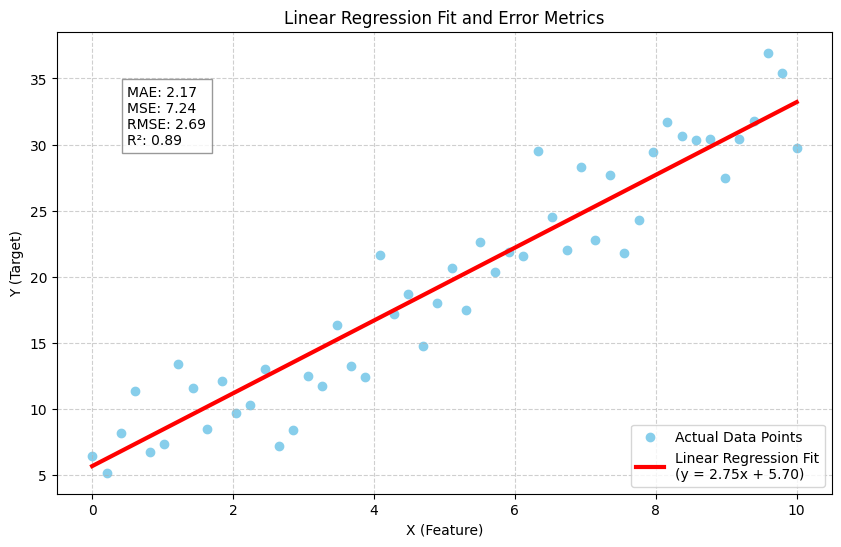

In [9]:
y_plot_pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='skyblue', label='Actual Data Points')
plt.plot(X, y_plot_pred, color='red', linewidth=3, label=f'Linear Regression Fit\n(y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})')
plt.title("Linear Regression Fit and Error Metrics")
plt.xlabel("X (Feature)")
plt.ylabel("Y (Target)")
plt.text(0.5, 30, f'MAE: {MAE:.2f}\nMSE: {MSE:.2f}\nRMSE: {RMSE:.2f}\nR²: {R2:.2f}',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
         fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()